In [ ]:

# 連接 Google Drive，讓 Colab 可以存取雲端檔案
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
# 建立 Kaggle 設定資料夾
os.makedirs('/root/.kaggle', exist_ok=True)
# 將 kaggle.json 複製到指定位置
os.system('cp kaggle.json /root/.kaggle/')
# 設定為私人權限，避免憑證外洩
os.system('chmod 600 /root/.kaggle/kaggle.json')

0

In [ ]:
# 從 Kaggle 下載肺炎 X 光資料集（約 2GB）
os.system('kaggle datasets download -d paultimothymooney/chest-xray-pneumonia')
# 解壓縮到 /content/chest-xray 資料夾
os.system('unzip chest-xray-pneumonia.zip -d /content/chest-xray')

0

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image

# 確認資料集是否正確下載
print(os.listdir("/content/chest-xray"))

# 載入深度學習相關套件
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from sklearn.metrics import classification_report, confusion_matrix

['chest_xray']


In [ ]:
mainDIR = os.listdir('/content/chest-xray/chest_xray')
print(mainDIR)

['__MACOSX', 'train', 'val', 'test', 'chest_xray']


In [ ]:
# 設定訓練、驗證、測試資料夾路徑
train_folder = '/content/chest-xray/chest_xray/train/'
val_folder = '/content/chest-xray/chest_xray/val/'
test_folder = '/content/chest-xray/chest_xray/train/'

In [ ]:
# 分別設定正常與肺炎的訓練資料路徑
os.listdir(train_folder)
train_n = train_folder + 'NORMAL/'    # 正常 X 光
train_p = train_folder + 'PNEUMONIA/' # 肺炎 X 光

## 資料視覺化
隨機抽取一張正常與一張肺炎 X 光併排顯示，
顯示兩類影像的差異。

1341
normal picture title:  NORMAL2-IM-0659-0001.jpeg
pneumonia picture title: person1184_virus_2019.jpeg


Text(0.5, 1.0, 'Pneumonia')

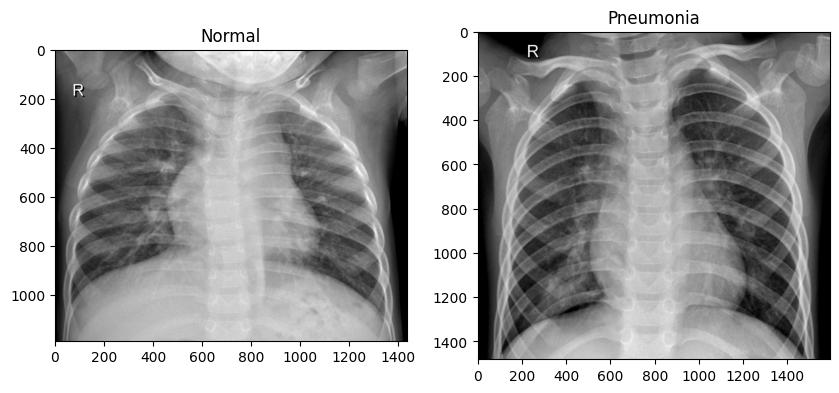

In [ ]:
# 印出正常 X 光訓練資料總張數
print(len(os.listdir(train_n)))

# 正常 X 光：隨機選一張
rand_norm = np.random.randint(0, len(os.listdir(train_n)))  # 隨機產生索引
norm_pic = os.listdir(train_n)[rand_norm]                   # 取得檔案名稱
norm_pic_address = train_n + norm_pic                       # 合併成完整路徑
print('normal picture title: ', norm_pic)

# 肺炎 X 光：隨機選一張
rand_p = np.random.randint(0, len(os.listdir(train_p)))     # 隨機產生索引
sic_pic = os.listdir(train_p)[rand_norm]                    # 取得檔案名稱
sic_address = train_p + sic_pic                             # 合併成完整路徑
print('pneumonia picture title:', sic_pic)

# 用 PIL 打開正常&肺炎 X 光
norm_load = Image.open(norm_pic_address)
sic_load = Image.open(sic_address)

# 並排顯示兩張圖片
f = plt.figure(figsize= (10,6))

a1 = f.add_subplot(1,2,1)
img_plot = plt.imshow(norm_load, cmap='gray')  # 顯示正常 X 光
a1.set_title('Normal')

a2 = f.add_subplot(1, 2, 2)
img_plot = plt.imshow(sic_load, cmap='gray')   # 顯示肺炎 X 光
a2.set_title('Pneumonia')

## 建立 CNN 模型

採用兩層卷積（Conv2D）+ 池化（MaxPooling2D）的架構：

| 層級 | 類型 | 作用 |
|------|------|------|
| 第1層 | Conv2D | 找出基本特徵（邊緣、紋理）|
| 第2層 | MaxPooling2D | 縮小特徵圖，保留重要資訊 |
| 第3層 | Conv2D | 學習更複雜的特徵 |
| 第4層 | MaxPooling2D | 再次縮小特徵圖 |
| 第5層 | Flatten | 攤平成一維 |
| 第6層 | Dense(128) | 全連接層，整合特徵 |
| 第7層 | Dense(1) | 輸出肺炎機率（0~1）|

In [ ]:
cnn = Sequential()

#Convolution
cnn.add(Conv2D(32,      #用32個濾鏡掃描圖片
              (3, 3),   #每個濾鏡大小是 3x3 像素
               activation="relu",
               input_shape=(64, 64, 3)))

#Pooling
cnn.add(MaxPooling2D(pool_size = (2, 2)))

# 2nd Convolution
cnn.add(Conv2D(32, (3, 3), activation="relu"))

# 2nd Pooling layer
cnn.add(MaxPooling2D(pool_size = (2, 2)))

# Flatten the layer
cnn.add(Flatten())

# Fully Connected Layers
cnn.add(Dense(activation='relu', units=128))    # 中間層：128個神經元
cnn.add(Dense(activation='sigmoid', units=1))   # 輸出層：輸出肺炎機率(0~1)

# Compile the Neural network
cnn.compile(
    optimizer='adam',              # 優化器：自動調整學習速度
    loss='binary_crossentropy',    # 損失函數：衡量預測與正確答案的差距
    metrics=['accuracy']           # 追蹤指標：顯示每輪的準確率
)

## 資料前處理與載入

訓練集使用資料增強（縮放、翻轉）增加多樣性；驗證集與測試集僅做像素正規化。

| 資料集 | 張數 | 用途 |
|--------|------|------|
| 訓練集 | 5216 | 訓練模型 |
| 驗證集 | 16   | 監控過擬合 |
| 測試集 | 624  | 最終評估準確率 |

In [ ]:
# 訓練集資料增強：增加圖片多樣性，讓模型學到更多變化
train_datagen = ImageDataGenerator(
    rescale=1./255,          # 像素值縮小到 0~1，讓模型好學習
    shear_range=0,           # 錯切變形（設為0代表不使用）
    zoom_range=0.2,          # 隨機縮放圖片
    horizontal_flip=True)    # 隨機水平翻轉圖片

# 驗證集、測試集：只做正規化，不需要增強
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# 從資料夾讀取訓練集圖片
training_set = train_datagen.flow_from_directory(
    '/content/chest-xray/chest_xray/chest_xray/train',
    target_size=(64, 64),    # 統一縮放成 64x64 像素
    batch_size=32,           # 每次讀取 32 張
    class_mode='binary')     # 二元分類（肺炎/正常）

# 從資料夾讀取驗證集圖片
validation_generator = val_datagen.flow_from_directory(
    '/content/chest-xray/chest_xray/chest_xray/val/',
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary')

# 從資料夾讀取測試集圖片
test_set = test_datagen.flow_from_directory(
    '/content/chest-xray/chest_xray/chest_xray/test',
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary')

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


## 模型訓練與評估結果

測試不同訓練輪數對準確率的影響：

| epochs | 訓練準確率 | 測試準確率 |
|--------|-----------|-----------|
| 1      | 90.11%    | 88.96%    |
| 5      | 95.86%    | 89.26%    |
| 10     | 94.90%    | 85.41%    |

epochs=5 表現最佳，epochs=10 出現過擬合現象。

> 驗證集僅 16 張，結果波動大，僅供參考。

In [ ]:
cnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 29, 29, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 813,217 (3.10 MB)

 Trainable params: 813,217 (3.10 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 訓練模型
cnn_model = cnn.fit(
    training_set,           # 訓練資料來源
    steps_per_epoch=163,    # 每輪批次數（5216張 ÷ 32批 = 163）
    epochs=5,              # 整個訓練集跑5遍
    validation_data=validation_generator,  # 每輪結束後用驗證集檢查
    validation_steps=1      # 驗證集批次數（16張 ÷ 32批 ≈ 1）
)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 55s 337ms/step - accuracy: 0.9515 - loss: 0.1347 - val_accuracy: 0.6250 - val_loss: 0.8047
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 55s 336ms/step - accuracy: 0.9576 - loss: 0.1127 - val_accuracy: 0.7500 - val_loss: 0.5087
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 54s 329ms/step - accuracy: 0.9538 - loss: 0.1170 - val_accuracy: 0.8125 - val_loss: 0.3369
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 55s 333ms/step - accuracy: 0.9563 - loss: 0.1148 - val_accuracy: 0.6250 - val_loss: 0.8854
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 55s 335ms/step - accuracy: 0.9586 - loss: 0.1155 - val_accuracy: 0.6875 - val_loss: 0.6493


In [ ]:
test_accu = cnn.evaluate(test_set, steps=20)
print('The testing accuracy is :',test_accu[1]*100, '%')

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 218ms/step - accuracy: 0.8926 - loss: 0.3812
The testing accuracy is : 89.26281929016113 %


In [ ]:
# 用模型對測試集所有圖片做預測
Y_pred = cnn.predict(test_set, steps=20)

# sigmoid 輸出機率，用 0.5 當門檻判斷類別
y_pred = (Y_pred > 0.5).astype(int).flatten()
print(y_pred)

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 308ms/step
[0 1 1 1 1 1 1 1 1 1 0 1 0 1 0 1 1 1 1 0 1 1 1 0 1 0 1 1 1 1 0 0 1 0 1 1 0
 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1 0 0 1 1 0 0 1 1 1 1 1 1 0 1 1 1 0 1 0 1 1 1
 1 0 1 0 0 1 1 0 1 0 1 1 0 0 1 1 0 1 1 0 1 1 1 0 0 1 1 0 1 1 1 1 1 1 1 1 0
 1 0 1 1 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 0 1
 1 1 0 1 0 1 1 0 1 0 1 0 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1
 0 0 0 1 1 0 0 1 1 1 1 1 1 1 1 1 0 1 1 0 1 1 0 1 1 1 1 0 1 1 0 1 1 0 1 1 1
 1 0 1 1 0 1 1 1 0 0 1 0 1 0 1 1 1 1 1 1 1 1 1 1 0 1 0 0 1 0 1 1 0 1 1 1 1
 1 1 1 1 0 1 0 0 1 1 0 0 1 0 1 1 0 1 0 1 1 0 0 1 1 1 1 1 0 1 1 1 1 0 1 0 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 0 1 0 1 1 1 0 0 0 0 0 0 1
 0 1 1 1 1 1 0 0 1 1 1 0 1 0 1 1 0 1 0 1 1 0 1 1 1 0 0 0 1 1 1 0 1 1 1 1 1
 1 1 1 0 1 1 1 1 1 0 0 1 1 1 0 1 0 0 1 1 0 1 1 1 1 1 1 0 1 0 1 1 1 1 1 0 1
 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 0 1 1 1 0 1 0 1 1 1 1 1 1 0 1 0 1 1 1 1 1
 1 1 0 1 0 1 1 1 0 0 1 0 0 0 1 1 1 1 1 1 0 1 0 0 1 1 1 1 1 

In [ ]:
# 確認預測結果包含兩種類別（0和1），代表模型運作正常
max(y_pred)

np.int64(1)

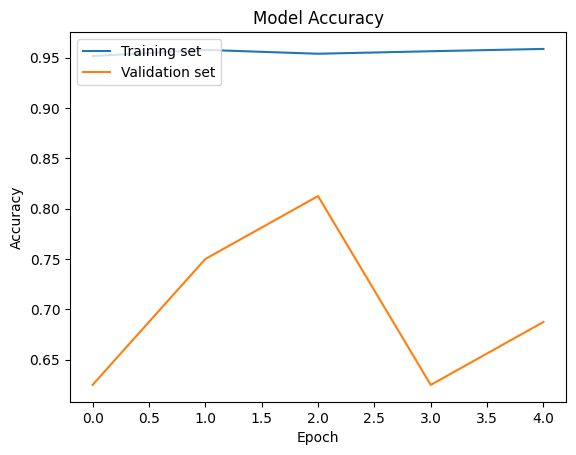

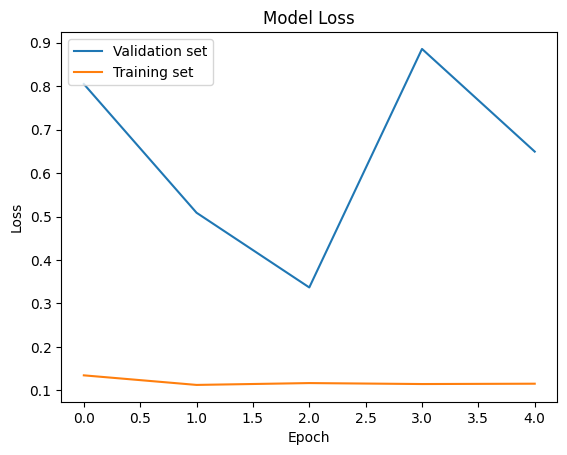

In [ ]:
# 視覺化訓練過程：訓練集 vs 驗證集的準確率與損失值變化

# Accuracy
plt.plot(cnn_model.history['accuracy'])
plt.plot(cnn_model.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training set', 'Validation set'], loc='upper left')
plt.show()

# Loss
plt.plot(cnn_model.history['val_loss'])
plt.plot(cnn_model.history['loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Validation set', 'Training set'], loc='upper left')
plt.show()